In [1]:
##-RUSHDA QURESHI-2503951-MSBAWE2


In [2]:
#-Import  libraries
import pandas as pd


In [3]:
import numpy as np


In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns

In [6]:
from sklearn.model_selection import train_test_split, cross_val_score

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [8]:
from sklearn.linear_model import LogisticRegression, LinearRegression

In [9]:
from sklearn.metrics import classification_report, mean_squared_error, confusion_matrix


In [22]:
# 1. Load the data properly as an Excel file
df = pd.read_excel('Bank.xlsx')

In [23]:
# 2. Preview the raw Excel data
print("--- Excel Data Preview ---")
print(df.head())

--- Excel Data Preview ---
   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  


In [24]:
# 3. Check for standard missing values (NaN)
print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())


--- Missing Values Per Column ---
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [25]:
# 3. Check for standard missing values (NaN)
print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())


--- Missing Values Per Column ---
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [14]:
# 5. Check and remove exact duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\n--- Duplicates found: {duplicate_count} ---")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed successfully.")


--- Duplicates found: 0 ---


In [26]:
# 6. SAVE IT STRICLY AS AN EXCEL FILE (.xlsx)
df.to_excel('Bank_Cleaned.xlsx', index=False)

print("\nSuccess! The data is clean and saved as 'bank_cleaned.xlsx'")


Success! The data is clean and saved as 'bank_cleaned.xlsx'


In [27]:
##-Convert numerical columns from text strings back to numbers so math functions work
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [28]:
print("Dataset Shape:", df.columns)
print(df.head())

Dataset Shape: Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')
   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199  

In [29]:
##-Display the successful structure breakdown
print(f"Success! Dataset split into: {df.shape[0]} rows, {df.shape[1]} proper columns\n")
print("--- Cleaned Column List ---")
print(df.columns.tolist())

Success! Dataset split into: 4521 rows, 17 proper columns

--- Cleaned Column List ---
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']



Descriptive Statistics:
                age       balance          day     duration     campaign  \
count  4521.000000   4521.000000  4521.000000  4521.000000  4521.000000   
mean     41.170095   1422.657819    15.915284   263.961292     2.793630   
std      10.576211   3009.638142     8.247667   259.856633     3.109807   
min      19.000000  -3313.000000     1.000000     4.000000     1.000000   
25%      33.000000     69.000000     9.000000   104.000000     1.000000   
50%      39.000000    444.000000    16.000000   185.000000     2.000000   
75%      49.000000   1480.000000    21.000000   329.000000     3.000000   
max      87.000000  71188.000000    31.000000  3025.000000    50.000000   

             pdays     previous  
count  4521.000000  4521.000000  
mean     39.766645     0.542579  
std     100.121124     1.693562  
min      -1.000000     0.000000  
25%      -1.000000     0.000000  
50%      -1.000000     0.000000  
75%      -1.000000     0.000000  
max     871.000000    25.0

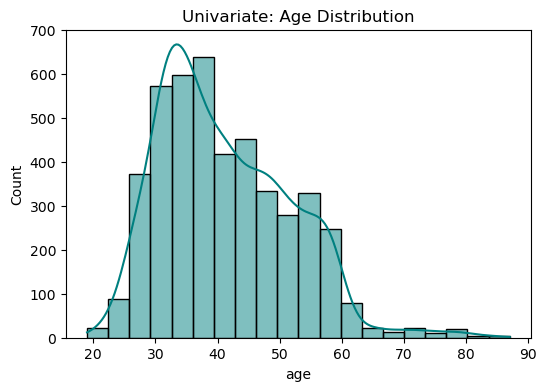

In [30]:
# 3. Exploratory Data Analysis (EDA)
# 4. Univariate analysis
print("\nDescriptive Statistics:\n", df.describe())
plt.figure(figsize=(6, 4))
sns.histplot(df['age'], bins=20, kde=True, color='teal')
plt.title('Univariate: Age Distribution')
plt.show()

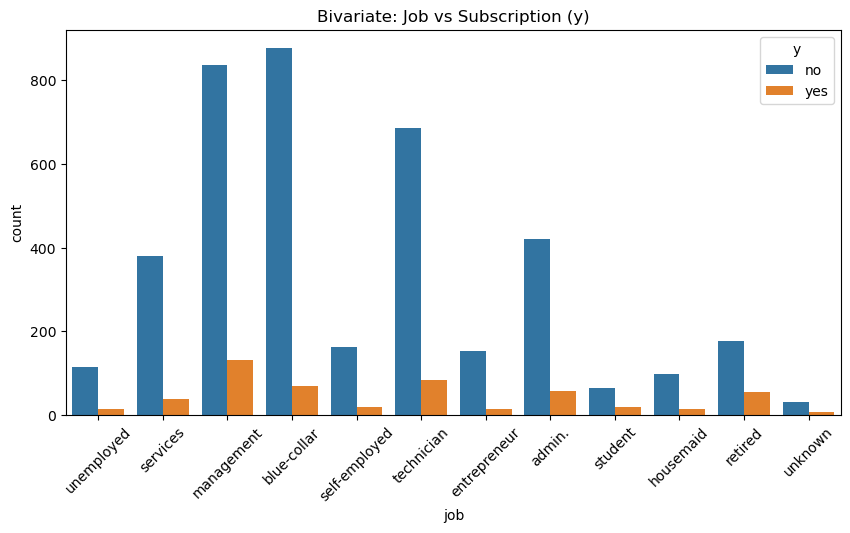

In [31]:
# 5. Bivariate analysis: Grouped bar chart (Target vs Category)
plt.figure(figsize=(10, 5))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=45)
plt.title('Bivariate: Job vs Subscription (y)')
plt.show()

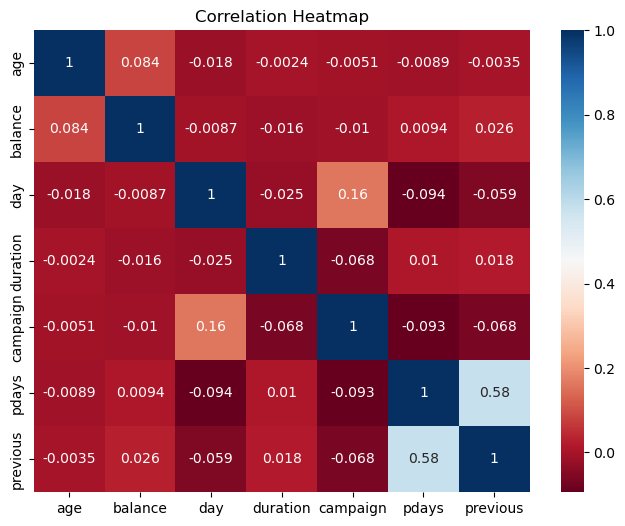

In [35]:
# 6. Correlation matrix and heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='RdBu')
plt.title('Correlation Heatmap')
plt.show()

In [36]:
# 7. Class imbalance
print("\nClass Proportions:\n", df['y'].value_counts(normalize=True))


Class Proportions:
 y
no     0.88476
yes    0.11524
Name: proportion, dtype: float64


In [37]:
# 8. Outlier detection (Z-scores)
z_scores = np.abs((df['balance'] - df['balance'].mean()) / df['balance'].std())
print(f"Balance Outliers (Z > 3): {(z_scores > 3).sum()}")

Balance Outliers (Z > 3): 88


In [38]:
# 10. Feature Engineering
# 12. Engineer new features
df['financial_obligation'] = ((df['housing'] == 'yes') | (df['loan'] == 'yes')).astype(int)
df['contact_success'] = (df['poutcome'] == 'success').astype(int)

In [39]:
# 13. Encode categorical variables
# Drop 'duration' as per lab notes (not available before the call ends)
X = df.drop(['y', 'duration'], axis=1)
X = pd.get_dummies(X, drop_first=True)

le = LabelEncoder()
y = le.fit_transform(df['y'])

In [40]:
# --- SAVE CLEANED DATASET ---
df.to_csv('cleaned_bank_data_final.csv', index=False)
print("\nCleaned dataset saved as 'cleaned_bank_data_final.csv'")


Cleaned dataset saved as 'cleaned_bank_data_final.csv'


In [41]:
# 15. Train/Test Split and Cross-Validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [42]:
# 14. Scale numerical variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
# 18. Cross-validation (Logistic Regression)
log_reg = LogisticRegression(max_iter=1000)
cv_acc = cross_val_score(log_reg, X_train_scaled, y_train, cv=5)
print(f"\nLogistic Regression CV Accuracy: {cv_acc.mean():.4f}")


Logistic Regression CV Accuracy: 0.8938


In [44]:
# 21. Logistic Regression Model & Confusion Matrix
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94       801
           1       0.52      0.15      0.24       104

    accuracy                           0.89       905
   macro avg       0.71      0.57      0.59       905
weighted avg       0.86      0.89      0.86       905



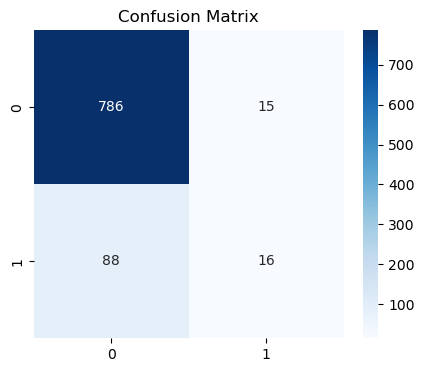

In [45]:
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [46]:
# 22. Interpretation
importance = pd.DataFrame({'Feature': X.columns, 'Coef': log_reg.coef_[0]})
print("\nTop 5 Predictors:\n", importance.sort_values(by='Coef', ascending=False).head(5))


Top 5 Predictors:
              Feature      Coef
7    contact_success  0.201232
41  poutcome_success  0.201232
38         month_oct  0.198772
34         month_jun  0.135759
12       job_retired  0.135239
